# Automated Trading using Python

Playground for algorithmic trading strategies.



### Import

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d

import openmeteo_requests

from openmeteo_sdk.Variable import Variable
from openmeteo_sdk.Aggregation import Aggregation

import requests_cache
from retry_requests import retry

### Data

In [132]:
# wind power production vs. wind speed
xs = np.arange(0,43)
ys = np.array([0,0,0,55,175,410,760,1250,1900,2700,3750,4850,5750,6500,7000,7350,7500,7580,7580,7580,7580,7580,7580,7580,7580,7580, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])
interp_func = interp1d(xs, ys) 

In [133]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://ensemble-api.open-meteo.com/v1/ensemble"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"hourly": ["wind_speed_80m"],
	"models": "icon_seamless",
	"forecast_days": 3,
	"wind_speed_unit": "ms"
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]

# Process hourly data
hourly = response.Hourly()
hourly_variables = list(map(lambda i: hourly.Variables(i), range(0, hourly.VariablesLength())))
hourly_wind_speed_80m = filter(lambda x: x.Variable() == Variable.wind_speed and x.Altitude() == 80, hourly_variables)

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

for variable in hourly_wind_speed_80m:
	member = variable.EnsembleMember()
	hourly_data[f"wind_power_80m_member{member}"] = interp_func(variable.ValuesAsNumpy())

hourly_dataframe = pd.DataFrame(data = hourly_data)
del hourly_dataframe['date']
hourly_dataframe['day_ahead_forecast'] = hourly_dataframe.mean(axis=1)

In [221]:
# Sample data
np.random.seed(42)
n = 72
timestamps = pd.date_range("2025-01-01", periods=n, freq="h")

# Get probabilistic forecast quantiles 
forecast_std_dev = hourly_dataframe.std(axis=1)
forecast_p10 = hourly_dataframe.apply(lambda row: np.percentile(row, 10), axis=1)
forecast_p90 = hourly_dataframe.apply(lambda row: np.percentile(row, 90), axis=1) 

# Simulated day-ahead and intraday production forecasts [MW]
day_ahead_forecast = hourly_dataframe['day_ahead_forecast']
intraday_forecast = day_ahead_forecast + np.random.normal(0, forecast_std_dev, n)
intraday_forecast[intraday_forecast < 0] = 0


# Simulated intraday price [€/MWh]
intraday_price = 80 + 0.01 * (day_ahead_forecast - intraday_forecast) + np.random.normal(0, 2, n)

# Simulated next-hour price (for exit price)
# simple rule: enter now, exit next hour -> assumption in backtest
exit_price = np.roll(intraday_price, -1)

df = pd.DataFrame({
    "timestamp": timestamps,
    "day_ahead_forecast": day_ahead_forecast,
    "intraday_forecast": intraday_forecast,
    "intraday_price": intraday_price,
    "forecast_std_dev": forecast_std_dev,
    "exit_price": exit_price,
    "forecast_p10": forecast_p10,
    "forecast_p90": forecast_p90
})

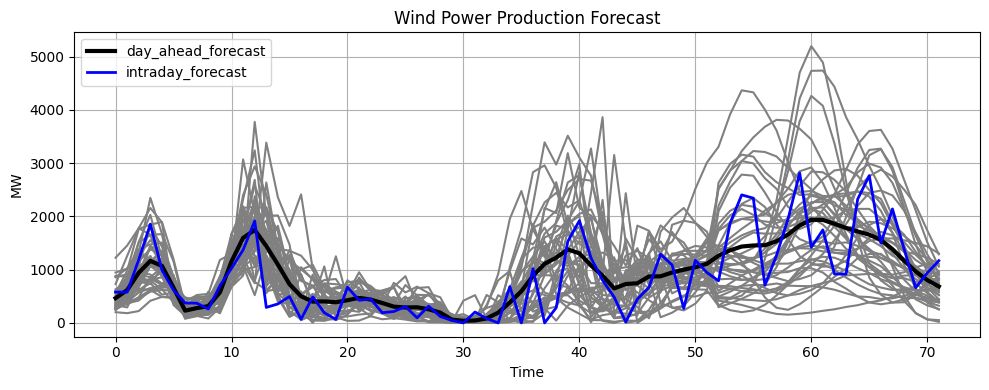

In [222]:
plt.figure(figsize=(10, 4))
for i in hourly_dataframe.columns:
    plt.plot(hourly_dataframe[i],color='grey')
plt.plot(hourly_dataframe['day_ahead_forecast'],lw = 3, color='black',label='day_ahead_forecast')
plt.plot(intraday_forecast,lw = 2, color='blue',label='intraday_forecast',linestyle='-')
plt.title("Wind Power Production Forecast")
plt.xlabel("Time")
plt.ylabel("MW")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Parameters

In [227]:
# Strategy parameters
threshold = 0  # MW
transaction_cost = 0.01  # €/MWh

### Simple Strategy 

- Buy if intraday production forecast is lower than day-ahead: production is falling -> price likely to rise.
- Sell if intraday forecast is higher than day-ahead: production is rising -> price likely to fall.

Trade only if the difference exceeds a defined threshold.

Summary Statistics:
Mean PnL: -1746.676 €/MWh
Std Dev: 3952.250
Sharpe Ratio: -0.44
Win Rate: 29.58%
Number of trades: 72


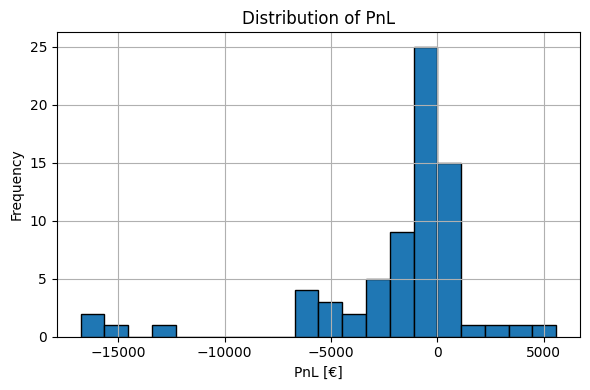

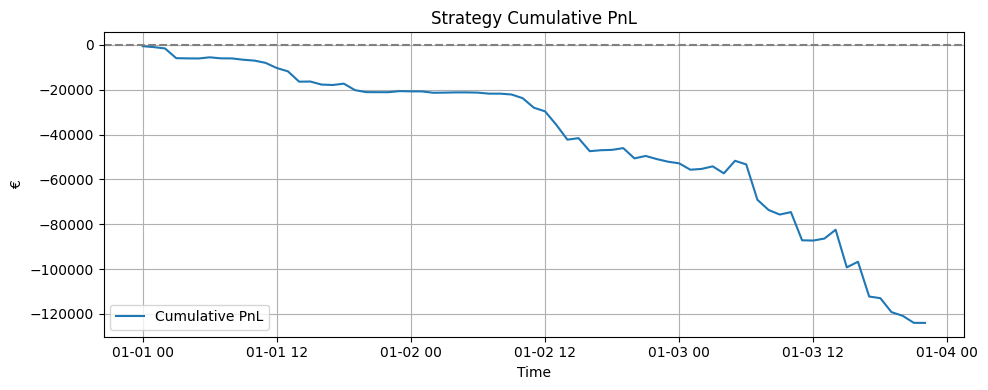

In [228]:
df["forecast_diff"] = df["intraday_forecast"] - df["day_ahead_forecast"]
df["signal"] = 0
df.loc[df["forecast_diff"] > threshold, "signal"] = -1  # More production -> prices fall -> sell
df.loc[df["forecast_diff"] < -threshold, "signal"] = 1  # Less production -> prices rise -> buy


df["exit_price"] = df["intraday_price"].shift(-1)
df["price_change"] = df["exit_price"] - df["intraday_price"]
df["pnl"] = df["signal"] * df["price_change"] * df["forecast_diff"].abs() - abs(df["signal"]) * transaction_cost
# Cumulative PnL
df["cumulative_pnl"] = df["pnl"].cumsum()

pnl = df["pnl"].dropna()
print("Summary Statistics:")
print(f"Mean PnL: {pnl.mean():.3f} €/MWh")
print(f"Std Dev: {pnl.std():.3f}")
print(f"Sharpe Ratio: {pnl.mean() / pnl.std():.2f}")
print(f"Win Rate: {(pnl > 0).mean() * 100:.2f}%")
print(f"Number of trades: {np.count_nonzero(df['signal'])}")

plt.figure(figsize=(6, 4))
plt.hist(pnl, bins=20, edgecolor='k')
plt.title("Distribution of PnL")
plt.xlabel("PnL [€]")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["cumulative_pnl"], label="Cumulative PnL")
plt.axhline(0, linestyle='--', color='gray')
plt.title("Strategy Cumulative PnL")
plt.xlabel("Time")
plt.ylabel("€")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Combination of DAH auction and ID markets

Playground to explore a decision mechanism, on whether to go into the DAH auction or to compute a suitable bidding price for the DAH auction.